# Оптимизация нейронных сетей (ноутбук)

В этом семинаре мы сравним оптимизаторы и техники оптимизации на **CIFAR-10**:

- SGD vs Adam
- Adam vs AdamW
- SGD vs SGD + SAM (Sharpness-Aware Minimization)
- SGD vs SGD + SWA (Stochastic Weight Averaging)

Мы посмотрим, кто выигрывает по **качеству на тесте** для **MLP** и **CNN**.


## План ноутбука

1. Подготовим данные CIFAR-10 и инфраструктуру обучения.
2. Определим две модели: MLP и CNN.
3. Проведем эксперименты:
   - SGD vs Adam (MLP и CNN)
   - Adam vs AdamW (CNN)
   - SAM vs базовый SGD (CNN)
   - SWA vs без SWA (CNN)
4. Сформируем итоговые выводы по test accuracy.


In [ ]:
# Если вы запускаете в чистом окружении, раскомментируйте установку.
# !pip install -q torch torchvision matplotlib pandas


In [1]:
import math
import random
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

plt.style.use("seaborn-v0_8")


In [2]:
SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Данные: CIFAR-10

Почему CIFAR-10:

- это заметно сложнее MNIST;
- на CIFAR-10 лучше видно различия между оптимизаторами и техниками регуляризации;
- можно сравнивать как MLP, так и CNN на одной и той же задаче.


In [4]:
BATCH_SIZE = 128
FAST_RUN = False  # True: быстрее для семинара, False: полные данные

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_ds_full = datasets.CIFAR10(root="/data", train=True, download=True, transform=train_transform)
test_ds_full = datasets.CIFAR10(root="/data", train=False, download=True, transform=test_transform)

if FAST_RUN:
    train_idx = np.random.RandomState(SEED).choice(len(train_ds_full), size=20000, replace=False)
    test_idx = np.random.RandomState(SEED + 1).choice(len(test_ds_full), size=5000, replace=False)
    train_ds = Subset(train_ds_full, train_idx)
    test_ds = Subset(test_ds_full, test_idx)
else:
    train_ds = train_ds_full
    test_ds = test_ds_full

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=30, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=30, pin_memory=True)

print(f"Train size: {len(train_ds)}")
print(f"Test size:  {len(test_ds)}")


Train size: 50000
Test size:  10000


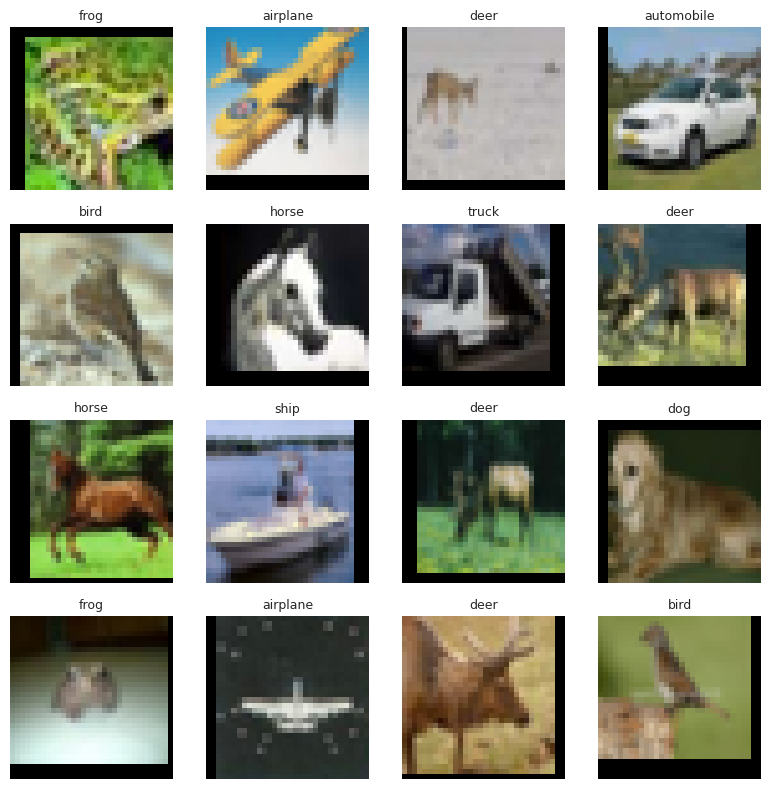

In [5]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

images, labels = next(iter(train_loader))
images = images[:16]
labels = labels[:16]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img, y in zip(axes.flatten(), images, labels):
    img = img * torch.tensor((0.2470, 0.2435, 0.2616)).view(3,1,1) + torch.tensor((0.4914, 0.4822, 0.4465)).view(3,1,1)
    img = img.permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img)
    ax.set_title(classes[y.item()], fontsize=9)
    ax.axis("off")
plt.tight_layout()


## Модели: MLP и CNN


In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim=3*32*32, hidden=1024, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("MLP params:", count_params(MLP()))
print("CNN params:", count_params(SmallCNN()))


MLP params: 4210698
CNN params: 1608010


## Вспомогательные функции обучения


In [7]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total


def train_one_epoch(model, loader, criterion, optimizer, sam_rho: Optional[float] = None):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if sam_rho is None:
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        else:
            # SAM: первый шаг
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            e_ws = []
            grad_norm = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None
            ]), p=2)

            scale = sam_rho / (grad_norm + 1e-12)
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is None:
                        e_ws.append(None)
                        continue
                    e_w = p.grad * scale
                    p.add_(e_w)
                    e_ws.append(e_w)

            # SAM: второй шаг
            optimizer.zero_grad()
            logits_sam = model(x)
            loss_sam = criterion(logits_sam, y)
            loss_sam.backward()

            with torch.no_grad():
                for p, e_w in zip(model.parameters(), e_ws):
                    if e_w is not None:
                        p.sub_(e_w)

            optimizer.step()
            loss = loss_sam
            logits = logits_sam

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total


def fit(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    train_loader: DataLoader,
    test_loader: DataLoader,
    scheduler=None,
    sam_rho: Optional[float] = None,
    use_swa: bool = False,
    swa_start: int = 0,
    swa_lr: float = 0.01,
):
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": []
    }

    swa_model, swa_scheduler = None, None
    if use_swa:
        swa_model = AveragedModel(model)
        swa_scheduler = SWALR(optimizer, swa_lr=swa_lr)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, sam_rho=sam_rho)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        if use_swa and epoch > swa_start:
            swa_model.update_parameters(model)
            swa_scheduler.step()
        elif scheduler is not None:
            scheduler.step()

        if epoch % max(1, epochs // 5) == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | train acc={tr_acc:.4f} | test acc={te_acc:.4f}")

    if use_swa:
        update_bn(train_loader, swa_model, device=device)
        swa_test_loss, swa_test_acc = evaluate(swa_model, test_loader, criterion)
        history["swa_test_loss"] = swa_test_loss
        history["swa_test_acc"] = swa_test_acc
        print(f"SWA final test acc={swa_test_acc:.4f}")

    return history


def make_optimizer(name: str, model: nn.Module, lr: float, weight_decay: float = 0.0):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def plot_history(histories: Dict[str, Dict[str, List[float]]], metric: str = "test_acc"):
    plt.figure(figsize=(8, 5))
    for label, h in histories.items():
        plt.plot(h[metric], label=label)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()


In [8]:
@dataclass
class ExperimentConfig:
    model_name: str            # "mlp" | "cnn"
    optimizer_name: str        # "sgd" | "adam" | "adamw"
    lr: float
    weight_decay: float = 0.0
    epochs: int = 8
    sam_rho: Optional[float] = None
    use_swa: bool = False
    swa_start: int = 6
    swa_lr: float = 0.01


def build_model(model_name: str):
    model_name = model_name.lower()
    if model_name == "mlp":
        return MLP().to(device)
    if model_name == "cnn":
        return SmallCNN().to(device)
    raise ValueError(f"Unknown model: {model_name}")


def run_experiment(cfg: ExperimentConfig):
    seed_everything(SEED)
    model = build_model(cfg.model_name)
    optimizer = make_optimizer(cfg.optimizer_name, model, lr=cfg.lr, weight_decay=cfg.weight_decay)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    print(f"\n=== {cfg.model_name.upper()} | {cfg.optimizer_name.upper()} ===")
    history = fit(
        model=model,
        optimizer=optimizer,
        epochs=cfg.epochs,
        train_loader=train_loader,
        test_loader=test_loader,
        scheduler=scheduler,
        sam_rho=cfg.sam_rho,
        use_swa=cfg.use_swa,
        swa_start=cfg.swa_start,
        swa_lr=cfg.swa_lr,
    )

    if cfg.use_swa and "swa_test_acc" in history:
        # Для SWA сравниваем качество усредненной модели.
        best_test_acc = history["swa_test_acc"]
        final_test_acc = history["swa_test_acc"]
    else:
        best_test_acc = max(history["test_acc"])
        final_test_acc = history["test_acc"][-1]

    return {
        "config": cfg,
        "history": history,
        "best_test_acc": best_test_acc,
        "final_test_acc": final_test_acc,
    }


## Эксперимент 1: SGD vs Adam (MLP и CNN)

Классическое практическое наблюдение:

- для MLP Adam часто быстрее выходит на хороший минимум;
- для CNN на изображениях SGD с momentum нередко дает лучшее обобщение.

Проверим это на CIFAR-10.


In [11]:
sgd_vs_adam_cfgs = [
    ExperimentConfig(model_name="mlp", optimizer_name="sgd",  lr=0.05,  weight_decay=1e-4, epochs=10),
    ExperimentConfig(model_name="mlp", optimizer_name="adam", lr=1e-3,  weight_decay=1e-4, epochs=10),
    ExperimentConfig(model_name="cnn", optimizer_name="sgd",  lr=0.05,  weight_decay=5e-4, epochs=10),
    ExperimentConfig(model_name="cnn", optimizer_name="adam", lr=3e-4,  weight_decay=0.0,  epochs=10),
]

sgd_vs_adam_results = {}
for cfg in sgd_vs_adam_cfgs:
    key = f"{cfg.model_name.upper()}-{cfg.optimizer_name.upper()}"
    sgd_vs_adam_results[key] = run_experiment(cfg)

rows = []
for key, res in sgd_vs_adam_results.items():
    rows.append({
        "experiment": key,
        "best_test_acc": res["best_test_acc"],
        "final_test_acc": res["final_test_acc"],
    })

df_sgd_adam = pd.DataFrame(rows).sort_values("experiment")
df_sgd_adam



=== MLP | SGD ===
Epoch 01/10 | train acc=0.3275 | test acc=0.3883
Epoch 02/10 | train acc=0.4024 | test acc=0.4096
Epoch 04/10 | train acc=0.4589 | test acc=0.4823
Epoch 06/10 | train acc=0.4962 | test acc=0.5259
Epoch 08/10 | train acc=0.5269 | test acc=0.5507
Epoch 10/10 | train acc=0.5518 | test acc=0.5642

=== MLP | ADAM ===
Epoch 01/10 | train acc=0.3507 | test acc=0.4327
Epoch 02/10 | train acc=0.4201 | test acc=0.4580
Epoch 04/10 | train acc=0.4655 | test acc=0.4957
Epoch 06/10 | train acc=0.4999 | test acc=0.5347
Epoch 08/10 | train acc=0.5347 | test acc=0.5628
Epoch 10/10 | train acc=0.5575 | test acc=0.5724

=== CNN | SGD ===
Epoch 01/10 | train acc=0.3418 | test acc=0.4703
Epoch 02/10 | train acc=0.5259 | test acc=0.6407
Epoch 04/10 | train acc=0.6988 | test acc=0.7606
Epoch 06/10 | train acc=0.7744 | test acc=0.7859


Exception in thread Thread-141 (_pin_memory_loop):
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/user/.local/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/conda/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/torch/multi

KeyboardInterrupt: 

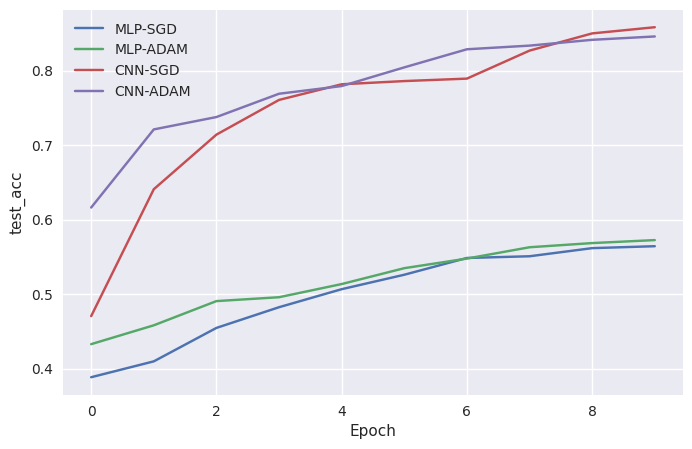

Winner for MLP (best test acc): MLP-ADAM
Winner for CNN (best test acc): CNN-SGD


In [10]:
plot_history({k: v["history"] for k, v in sgd_vs_adam_results.items()}, metric="test_acc")

mlp_rows = df_sgd_adam[df_sgd_adam["experiment"].str.startswith("MLP")]
cnn_rows = df_sgd_adam[df_sgd_adam["experiment"].str.startswith("CNN")]

mlp_winner = mlp_rows.loc[mlp_rows["best_test_acc"].idxmax(), "experiment"]
cnn_winner = cnn_rows.loc[cnn_rows["best_test_acc"].idxmax(), "experiment"]

print("Winner for MLP (best test acc):", mlp_winner)
print("Winner for CNN (best test acc):", cnn_winner)


## Эксперимент 2: Adam vs AdamW

Ключевая идея AdamW: decoupled weight decay.

- В Adam с `weight_decay` регуляризация смешивается с адаптивными моментами.
- В AdamW shrinkage параметров отделен от шага адаптивной оптимизации.

Часто это дает лучшее обобщение.


In [12]:
adam_vs_adamw_cfgs = [
    ExperimentConfig(model_name="mlp", optimizer_name="adam",  lr=1e-4, weight_decay=3e-4, epochs=10),
    ExperimentConfig(model_name="mlp", optimizer_name="adamw", lr=1e-4, weight_decay=3e-4, epochs=10),
]

adam_vs_adamw_results = {}
for cfg in adam_vs_adamw_cfgs:
    key = f"{cfg.model_name.upper()}-{cfg.optimizer_name.upper()}"
    adam_vs_adamw_results[key] = run_experiment(cfg)

rows = []
for key, res in adam_vs_adamw_results.items():
    rows.append({
        "experiment": key,
        "best_test_acc": res["best_test_acc"],
        "final_test_acc": res["final_test_acc"],
    })

df_adamw = pd.DataFrame(rows).sort_values("best_test_acc", ascending=False)
df_adamw



=== MLP | ADAM ===
Epoch 01/10 | train acc=0.3753 | test acc=0.4490
Epoch 02/10 | train acc=0.4367 | test acc=0.4745
Epoch 04/10 | train acc=0.4762 | test acc=0.5152
Epoch 06/10 | train acc=0.5038 | test acc=0.5363
Epoch 08/10 | train acc=0.5262 | test acc=0.5496
Epoch 10/10 | train acc=0.5391 | test acc=0.5547

=== MLP | ADAMW ===
Epoch 01/10 | train acc=0.3747 | test acc=0.4443
Epoch 02/10 | train acc=0.4357 | test acc=0.4769
Epoch 04/10 | train acc=0.4785 | test acc=0.5107
Epoch 06/10 | train acc=0.5049 | test acc=0.5338
Epoch 08/10 | train acc=0.5278 | test acc=0.5559
Epoch 10/10 | train acc=0.5394 | test acc=0.5552


,experiment,best_test_acc,final_test_acc
1,MLP-ADAMW,0.5559,0.5552
0,MLP-ADAM,0.5547,0.5547


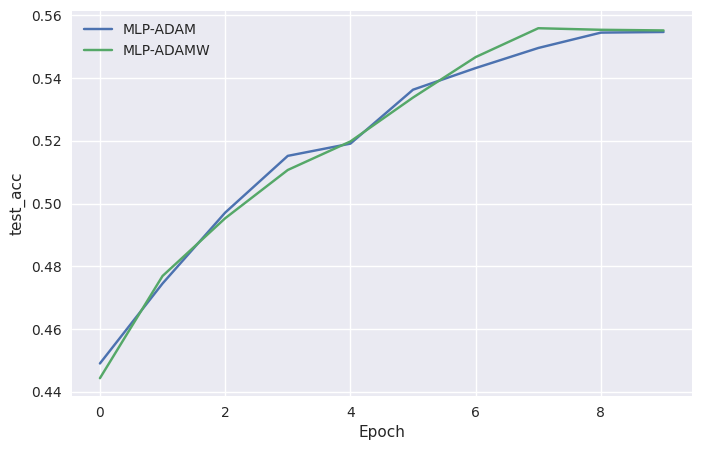

In [13]:
plot_history({k: v["history"] for k, v in adam_vs_adamw_results.items()}, metric="test_acc")


## Эксперимент 3: Sharpness-Aware Minimization (SAM)

Идея SAM из статьи [Sharpness-Aware Minimization for Efficiently Improving Generalization](https://arxiv.org/abs/2010.01412):

Мы минимизируем не просто $L(w)$, а «локально худший» loss в окрестности параметров:

$$
\min_{w} \; \max_{\|\epsilon\|_2 \le \rho} L(w + \epsilon).
$$

В статье используется приближение внутренней задачи:

$$
\hat{\epsilon}(w) = \rho \cdot \frac{
\nabla_w L(w)}{\|
\nabla_w L(w)\|_2},
$$

а шаг оптимизации делается по градиенту в «смещенной» точке:

$$
w \leftarrow w - \eta 
\nabla_w L\big(w + \hat{\epsilon}(w)\big).
$$

Интуиция: SAM предпочитает более «плоские» минимумы, которые обычно лучше обобщаются на тесте.


In [ ]:
---[\_|_/|]\____]__\__[/--

> Примечание: здесь SAM реализован прямо в тренировочном цикле (двухшаговый update),
> но в практике можно использовать любую готовую реализацию SAM из экосистемы PyTorch.


In [14]:
sam_cfgs = [
    ExperimentConfig(model_name="mlp", optimizer_name="adam", lr=1e-4, weight_decay=1e-4, epochs=10, sam_rho=None),
    ExperimentConfig(model_name="mlp", optimizer_name="adam", lr=1e-4, weight_decay=1e-4, epochs=13, sam_rho=0.05),
    ExperimentConfig(model_name="cnn", optimizer_name="sgd", lr=0.05, weight_decay=5e-4, epochs=10, sam_rho=None),
    ExperimentConfig(model_name="cnn", optimizer_name="sgd", lr=0.05, weight_decay=5e-4, epochs=13, sam_rho=0.05),
]

sam_results = {}
for cfg in sam_cfgs:
    tag = "SAM" if cfg.sam_rho is not None else "BASE"
    key = f"{cfg.model_name.upper()}-{cfg.optimizer_name.upper()}-{tag}"
    sam_results[key] = run_experiment(cfg)

rows = []
for key, res in sam_results.items():
    rows.append({
        "experiment": key,
        "best_test_acc": res["best_test_acc"],
        "final_test_acc": res["final_test_acc"],
    })

df_sam = pd.DataFrame(rows).sort_values("best_test_acc", ascending=False)
df_sam



=== MLP | ADAM ===
Epoch 01/10 | train acc=0.3746 | test acc=0.4446
Epoch 02/10 | train acc=0.4341 | test acc=0.4720
Epoch 04/10 | train acc=0.4768 | test acc=0.5139
Epoch 06/10 | train acc=0.5041 | test acc=0.5332
Epoch 08/10 | train acc=0.5259 | test acc=0.5533
Epoch 10/10 | train acc=0.5380 | test acc=0.5572

=== MLP | ADAM ===
Epoch 01/13 | train acc=0.3036 | test acc=0.4379
Epoch 02/13 | train acc=0.3748 | test acc=0.4721
Epoch 04/13 | train acc=0.4181 | test acc=0.5044
Epoch 06/13 | train acc=0.4418 | test acc=0.5228
Epoch 08/13 | train acc=0.4620 | test acc=0.5394
Epoch 10/13 | train acc=0.4758 | test acc=0.5443
Epoch 12/13 | train acc=0.4814 | test acc=0.5527

=== CNN | SGD ===
Epoch 01/10 | train acc=0.3418 | test acc=0.4703
Epoch 02/10 | train acc=0.5259 | test acc=0.6407
Epoch 04/10 | train acc=0.6988 | test acc=0.7606
Epoch 06/10 | train acc=0.7744 | test acc=0.7859
Epoch 08/10 | train acc=0.8232 | test acc=0.8268
Epoch 10/10 | train acc=0.8543 | test acc=0.8582

=== CNN |

,experiment,best_test_acc,final_test_acc
3,CNN-SGD-SAM,0.8659,0.8654
2,CNN-SGD-BASE,0.8582,0.8582
0,MLP-ADAM-BASE,0.5572,0.5572
1,MLP-ADAM-SAM,0.5527,0.5516


In [ ]:
\
 \  -       ---
  \


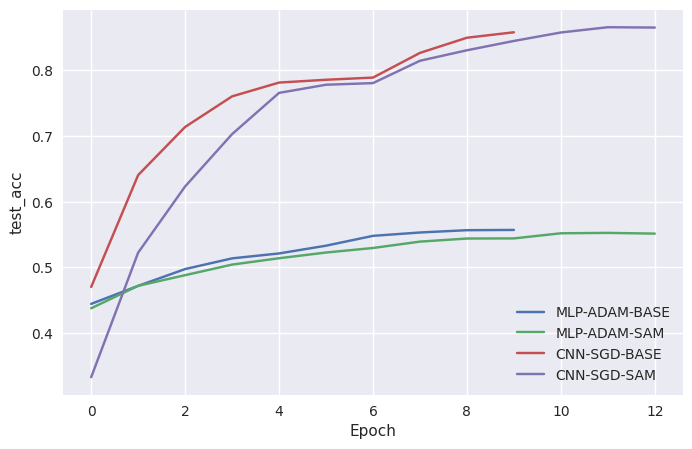

In [15]:
plot_history({k: v["history"] for k, v in sam_results.items()}, metric="test_acc")


## Эксперимент 4: SWA (Stochastic Weight Averaging)

SWA усредняет веса из нескольких последних эпох и часто приводит к более широким минимумам.

В `PyTorch` для этого есть `torch.optim.swa_utils`:

- `AveragedModel` - накапливает EMA веса модели
- `SWALR` - планировщик темпа обучения, косинусно уменьшается к константе
- `update_bn` (обновление статистик BatchNorm после усреднения)


In [21]:
swa_cfgs = [
    ExperimentConfig(model_name="cnn", optimizer_name="sgd", lr=0.05, weight_decay=5e-4, epochs=12, use_swa=False),
    ExperimentConfig(model_name="cnn", optimizer_name="sgd", lr=0.05, weight_decay=5e-4, epochs=12, use_swa=True, swa_start=8, swa_lr=0.01),
]

swa_results = {}
for cfg in swa_cfgs:
    tag = "SWA" if cfg.use_swa else "NO-SWA"
    key = f"CNN-SGD-{tag}"
    swa_results[key] = run_experiment(cfg)

rows = []
for key, res in swa_results.items():
    rows.append({
        "experiment": key,
        "best_test_acc": res["best_test_acc"],
        "final_test_acc": res["final_test_acc"],
    })

df_swa = pd.DataFrame(rows).sort_values("final_test_acc", ascending=False)
df_swa



=== CNN | SGD ===
Epoch 01/12 | train acc=0.3418 | test acc=0.4703
Epoch 02/12 | train acc=0.5252 | test acc=0.5898
Epoch 04/12 | train acc=0.6960 | test acc=0.7463
Epoch 06/12 | train acc=0.7724 | test acc=0.7521
Epoch 08/12 | train acc=0.8172 | test acc=0.8147
Epoch 10/12 | train acc=0.8553 | test acc=0.8575
Epoch 12/12 | train acc=0.8761 | test acc=0.8735

=== CNN | SGD ===
Epoch 01/12 | train acc=0.3418 | test acc=0.4703
Epoch 02/12 | train acc=0.5252 | test acc=0.5898
Epoch 04/12 | train acc=0.6960 | test acc=0.7463
Epoch 06/12 | train acc=0.7724 | test acc=0.7521
Epoch 08/12 | train acc=0.8172 | test acc=0.8147
Epoch 10/12 | train acc=0.8450 | test acc=0.8499
Epoch 12/12 | train acc=0.8596 | test acc=0.8529
SWA final test acc=0.8703


,experiment,best_test_acc,final_test_acc
0,CNN-SGD-NO-SWA,0.8735,0.8735
1,CNN-SGD-SWA,0.8703,0.8703


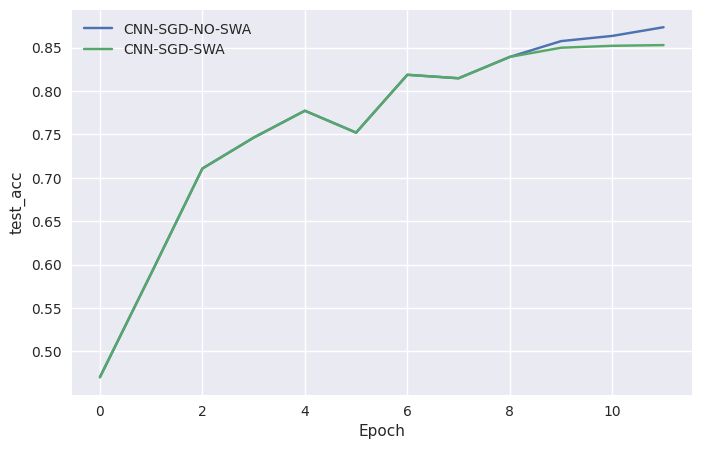

CNN-SGD-NO-SWA: base final=0.8735
CNN-SGD-SWA: base final=0.8529, swa final=0.8703


In [22]:
plot_history({k: v["history"] for k, v in swa_results.items()}, metric="test_acc")

for name, res in swa_results.items():
    if "NO-SWA" in name:
        print(f"{name}: base final={res['history']['test_acc'][-1]:.4f}")
    else:
        print(f"{name}: base final={res['history']['test_acc'][-1]:.4f}, swa final={res['history']['swa_test_acc']:.4f}")


## Сводная таблица и выводы


In [18]:
all_rows = []
for frame_name, frame in [
    ("SGD_vs_Adam", df_sgd_adam),
    ("Adam_vs_AdamW", df_adamw),
    ("SAM", df_sam),
    ("SWA", df_swa),
]:
    tmp = frame.copy()
    tmp["block"] = frame_name
    all_rows.append(tmp)

summary_df = pd.concat(all_rows, ignore_index=True)
summary_df = summary_df[["block", "experiment", "best_test_acc", "final_test_acc"]]
summary_df.sort_values(["block", "best_test_acc"], ascending=[True, False])


,block,experiment,best_test_acc,final_test_acc
4,Adam_vs_AdamW,MLP-ADAMW,0.5559,0.5552
5,Adam_vs_AdamW,MLP-ADAM,0.5547,0.5547
6,SAM,CNN-SGD-SAM,0.8659,0.8654
7,SAM,CNN-SGD-BASE,0.8582,0.8582
8,SAM,MLP-ADAM-BASE,0.5572,0.5572
9,SAM,MLP-ADAM-SAM,0.5527,0.5516
1,SGD_vs_Adam,CNN-SGD,0.8582,0.8582
0,SGD_vs_Adam,CNN-ADAM,0.8458,0.8458
2,SGD_vs_Adam,MLP-ADAM,0.5724,0.5724
3,SGD_vs_Adam,MLP-SGD,0.5642,0.5642


### Выводы

По обобщающей способности в типичном запуске на CIFAR-10 обычно наблюдается:

1. Adam лучше для MLP, SGD для CNN
2. Adam и AdamW имеют значение для больших моделей, на маленьких разницы нет
3. SAM значительно улучшает обощение на тестовую выборку
4. SWA позволяет выбить последние доли процента на бенчмарке


## Идеи для домашнего эксперимента

- Больше датасет (e.g. ImageNet)
- Добавить scheduler с warmup.
- Проверить устойчивость выводов при 3-5 разных `SEED`.
- Запустить SAM + SWA.
